# Autoencoder F1 Scores from CSV Outputs

This notebook reads the debug CSV files saved in `tmp/`, recomputes the `F1` score for each experiment from `y_test` and `y_pred`, and plots all experiments together in a single bar chart.


### PARAMETERS:


In [1]:
from pathlib import Path

tmp_dir = Path("tmp")
save_figure = False
figure_path = tmp_dir / "ae_f1_scores.png"
sort_descending = True


In [2]:
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from sklearn.metrics import f1_score

FEATURE_GROUPS = {
    "FLOW": ["bs", "ps", "br", "pr", "td"],
    "CTLS": ["tls.cver", "tls.ccs", "tls.cext", "tls.csg", "tls.alpn", "tls.csv"],
    "STLS": ["tls.sver", "tls.scs", "tls.sext", "tls.ssv"],
    "REC": ["tls.rec"],
}

FEATURE_SET_LOOKUP = {("full",): "FULL"}
group_names = list(FEATURE_GROUPS)
for size in range(1, len(group_names) + 1):
    for group_combo in combinations(group_names, size):
        feature_tokens = []
        for group_name in group_combo:
            feature_tokens.extend(FEATURE_GROUPS[group_name])
        FEATURE_SET_LOOKUP[tuple(feature_tokens)] = " + ".join(group_combo)

CLASS_COLORS = {
    "system": "#1f77b4",
    "malware": "#d62728",
    "application": "#2ca02c",
    "unknown": "#7f7f7f",
}

def format_feature_set(feature_key: str) -> str:
    tokens = tuple(feature_key.split("_"))
    return FEATURE_SET_LOOKUP.get(tokens, feature_key.replace("_", ", "))

def parse_experiment(csv_path: Path) -> dict:
    file_name = csv_path.name[:-4] if csv_path.name.endswith(".csv") else csv_path.name
    if not file_name.startswith("ae_"):
        raise ValueError(f"Unsupported file name: {csv_path.name}")

    remainder = file_name[len("ae_"):]
    if remainder.startswith("combined_"):
        variant = "Combined AE"
        remainder = remainder[len("combined_"):]
    else:
        variant = "AE"

    class_label, feature_key = remainder.split("_", 1)
    return {
        "Variant": variant,
        "ClassLabel": class_label,
        "FeatureSet": format_feature_set(feature_key),
        "FeatureKey": feature_key,
    }

def collect_scores(tmp_dir: Path) -> pd.DataFrame:
    csv_files = sorted(tmp_dir.glob("ae_*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No ae_*.csv files found in {tmp_dir.resolve()}")

    rows = []
    for csv_path in csv_files:
        frame = pd.read_csv(csv_path)
        required_columns = {"y_test", "y_pred"}
        missing_columns = required_columns.difference(frame.columns)
        if missing_columns:
            raise ValueError(f"Missing columns {sorted(missing_columns)} in {csv_path.name}")

        meta = parse_experiment(csv_path)
        score = f1_score(frame["y_test"], frame["y_pred"])
        rows.append({
            **meta,
            "F1Score": float(score),
            "Rows": int(len(frame)),
            "CsvFile": csv_path.name,
        })

    scores_df = pd.DataFrame(rows)
    scores_df["Experiment"] = (
        scores_df["Variant"] + " | " + scores_df["ClassLabel"] + " | " + scores_df["FeatureSet"]
    )
    scores_df = scores_df.sort_values("F1Score", ascending=not sort_descending).reset_index(drop=True)
    return scores_df

scores_df = collect_scores(tmp_dir)
display(scores_df[["Variant", "ClassLabel", "FeatureSet", "F1Score", "Rows", "CsvFile"]])
print(f"Loaded {len(scores_df)} experiments from {tmp_dir.resolve()}")


,Variant,ClassLabel,FeatureSet,F1Score,Rows,CsvFile
0,Combined AE,application,FULL,0.994414,213493,ae_combined_application_full.csv
1,AE,system,CTLS + REC,0.969297,197864,ae_system_tls.cver_tls.ccs_tls.cext_tls.csg_tl...
2,AE,system,CTLS + STLS,0.961549,197864,ae_system_tls.cver_tls.ccs_tls.cext_tls.csg_tl...
3,AE,system,REC,0.958881,197864,ae_system_tls.rec.csv
4,AE,unknown,STLS,0.954673,197864,ae_unknown_tls.sver_tls.scs_tls.sext_tls.ssv.csv
5,AE,system,FLOW + REC,0.953427,197864,ae_system_bs_ps_br_pr_td_tls.rec.csv
6,AE,system,FLOW + CTLS,0.946947,197864,ae_system_bs_ps_br_pr_td_tls.cver_tls.ccs_tls....
7,Combined AE,system,FULL,0.940910,213493,ae_combined_system_full.csv
8,Combined AE,unknown,FULL,0.938711,197864,ae_combined_unknown_full.csv
9,AE,unknown,REC,0.935715,197864,ae_unknown_tls.rec.csv


Loaded 29 experiments from /home/rysavy/devel/GitHub/AutoFedProfile/notebooks/aes/tmp


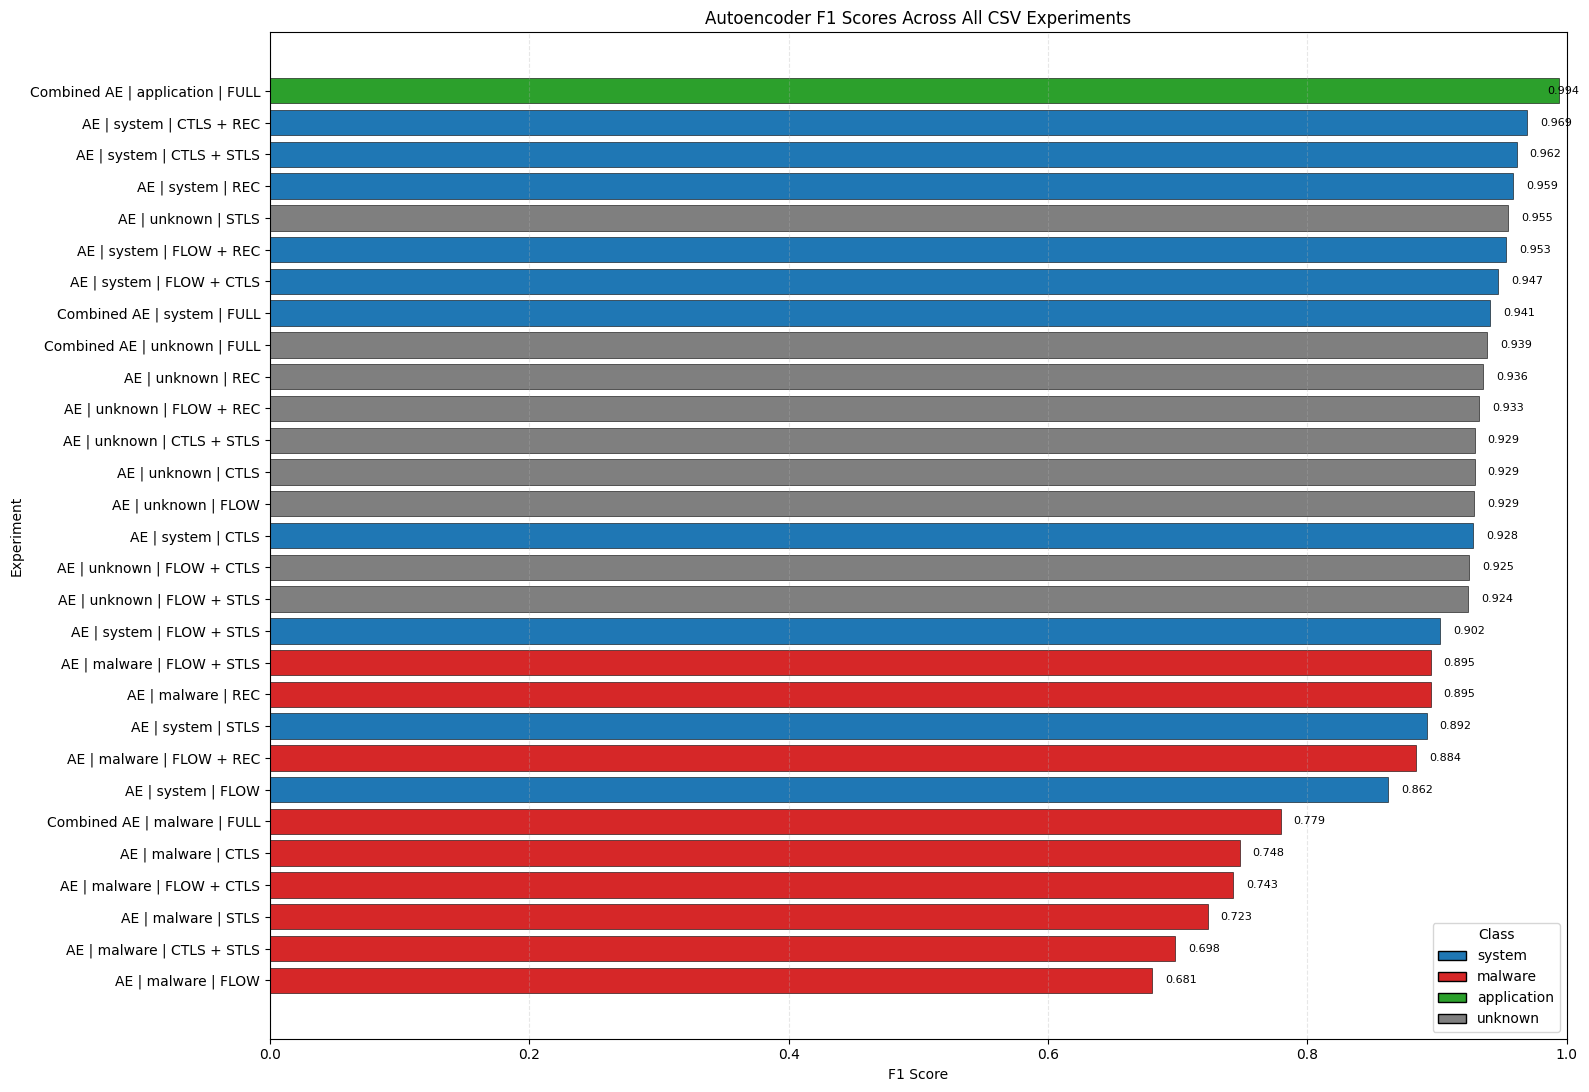

In [3]:
fig_height = max(8, 0.38 * len(scores_df))
fig, ax = plt.subplots(figsize=(16, fig_height))

bar_colors = [CLASS_COLORS.get(label, "#7f7f7f") for label in scores_df["ClassLabel"]]
bars = ax.barh(scores_df["Experiment"], scores_df["F1Score"], color=bar_colors, edgecolor="black", linewidth=0.4)

if sort_descending:
    ax.invert_yaxis()

for bar, score in zip(bars, scores_df["F1Score"]):
    y_pos = bar.get_y() + bar.get_height() / 2
    text_x = min(score + 0.01, 0.985)
    ax.text(text_x, y_pos, f"{score:.3f}", va="center", ha="left", fontsize=8)

present_labels = [label for label in CLASS_COLORS if label in set(scores_df["ClassLabel"])]
legend_handles = [Patch(facecolor=CLASS_COLORS[label], edgecolor="black", label=label) for label in present_labels]
ax.legend(handles=legend_handles, title="Class", loc="lower right")

ax.set_xlim(0, 1.0)
ax.set_xlabel("F1 Score")
ax.set_ylabel("Experiment")
ax.set_title("Autoencoder F1 Scores Across All CSV Experiments")
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

if save_figure:
    figure_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_path, dpi=200, bbox_inches="tight")
    print(f"Saved figure to {figure_path.resolve()}")

plt.show()
